In [1]:
e = 'CHIME'
from LIMxCMBL.init import *
from LIMxCMBL.experiments import *

/home/users/delon/.local/lib/python3.9/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [4]:
n_bins = 100

zmin = experiments[e]['zmin']
zmax = experiments[e]['zmax']
line_str = experiments[e]['line_str']

chimin = ccl.comoving_angular_distance(cosmo, 1/(1+zmin))
chimax = ccl.comoving_angular_distance(cosmo, 1/(1+zmax))

kpar_fundamental = 2*np.pi/(chimax - chimin)


chi_bin_edges = np.linspace(chimin*(1+1e-8), chimax*(1 - 1e-8), n_bins + 1)
chi_bin_centers = (chi_bin_edges[1:] + chi_bin_edges[:-1])/2
dchi_binned = np.mean(np.diff(chi_bin_edges))

In [7]:
from LIMxCMBL.noise import *

In [11]:
clean_cov = np.diag(f_eIeI(ls = chi_bin_edges[:-1], rs = chi_bin_edges[1:], dchi = dchi_binned))

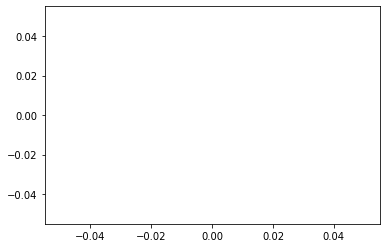

In [48]:
import matplotlib.pyplot as plt
from matplotlib import colors

plt.plot()
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 10,
    "font.family" : "serif",
    'figure.constrained_layout.use':True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'hatch.linewidth':0.1,
    'figure.figsize': (6, 6/1.618),
    'figure.constrained_layout.use': False,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})

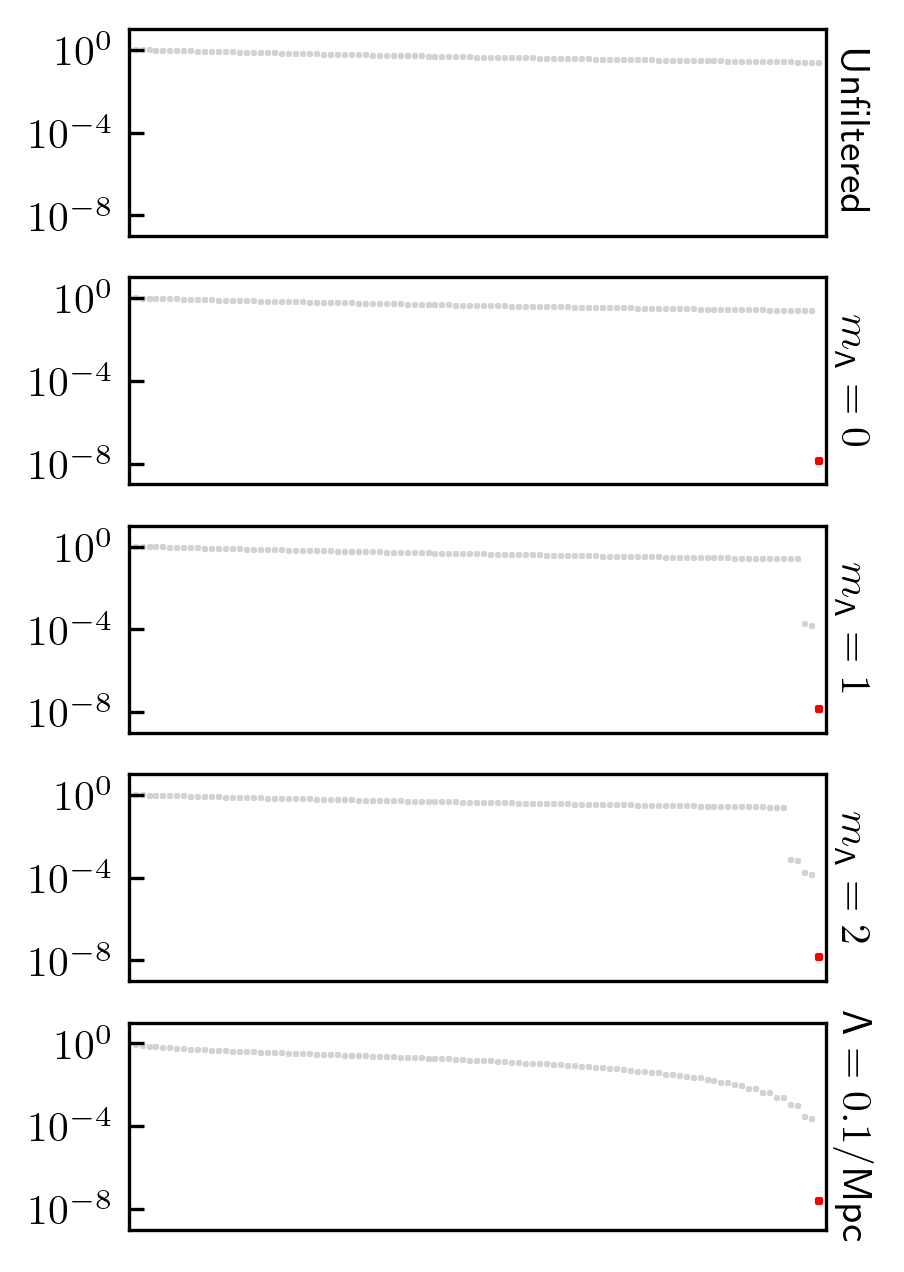

In [57]:
def plot_svd(ax, _cov, txt, cc='red', ss=1):
    U, s, Vt = np.linalg.svd(_cov)
    ax.scatter(np.arange(n_bins)[:-1], s[:-1]/s[0],
               marker=',', c='lightgrey', s=0.1,)
    
    ax.scatter(np.arange(n_bins)[-1], s[-1]/s[0],
               marker=',', c=cc, s=ss,)

    ax.set_yscale('log')
#     ax.set_ylim(1e-8, 3)
    ax.set_yticks([1e-8, 1e-4, 1e0])
    ax.set_ylim(1e-9, 1e1)
    ax.set_xlim(0, n_bins)
    ax.set_xticks([])
    
    ax.text(1.01, 0.5, txt,
            transform=ax.transAxes, 
            ha='left', va='center',
            fontsize=10,
            rotation=-90)

    return ax


fig, axs = plt.subplots(nrows = 5, ncols = 1, figsize = (3, 5.3), dpi=300)

plot_svd(axs[0], clean_cov, r'\textsf{Unfiltered}', cc='lightgrey', ss = 0.1)

LIDXs = experiments[e]['Lambda_idxs']
_LIDXs = [LIDXs[0], LIDXs[1], LIDXs[2], LIDXs[-1]]
txts = [r'$m_{\sf \Lambda}=0$', r'$m_{\sf \Lambda}=1$',  r'$m_{\sf \Lambda}=2$', r'${\sf \Lambda} = 0.1/{\sf Mpc}$']

for i,Lambda_idx in enumerate(_LIDXs):
    eComb_fname = '/scratch/users/delon/LIMxCMBL/eHIeHI/comb_'
    eComb_fname +='zmin_%.5f_zmax_%.5f_Lambda_idx_%.d_from_quad_nbins_%d.npy'%(zmin, 
                                                                               zmax, 
                                                                               Lambda_idx, 
                                                                               n_bins)

    eComb = np.load(eComb_fname)
    
    plot_svd(axs[i+1], eComb, txt=txts[i])
    ax.set_yscale('log')
    
